# Fixed income: versioned curve marks, restatements, carry & rolldown

A rates desk's core dataset is small but unforgiving: one par curve per
mark date, and every number on it feeds risk, P&L and client marks. The
natural h5i-db layout is *long format* — `(ts, tenor_years, yield_pct)` —
with one commit per mark date. That buys three things at once: SQL pivots
for any curve analytics, a version per EOD mark set (the audit trail
regulators actually ask about), and previewable restatements when a bad
contributor slips through.

We store 250 business days of curves — including one fat-fingered 10y mark
we plant deliberately — run slope/curvature analytics, *find* the bad mark
in SQL, restate it with `plan_replace_range`, and prove the pre-restatement
view is still queryable forever.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("prod_curves"), create=True)

curves = cu.make_yield_curves(days=250)  # ts, tenor_years, yield_pct — Nelson-Siegel dynamics
clean_df = curves.to_pandas()
mark_dates = clean_df["ts"].unique()

# Plant the incident: on mark date #120 the 10y prints 25bp too high
# (a stale contributor). This is what actually lands in the database.
feed_df = clean_df.copy()
bad_date = pd.Timestamp(mark_dates[120])
bad_mask = (feed_df["ts"] == bad_date) & (feed_df["tenor_years"] == 10.0)
feed_df.loc[bad_mask, "yield_pct"] += 0.25
print(f"vendor feed: {len(feed_df):,} rows, bad 10y mark on {bad_date.date()}")

vendor feed: 2,500 rows, bad 10y mark on 2025-12-16


## 1. One mark date = one commit

Each day's ten tenors are appended together: the commit *is* the mark set.
`versions()` then reads as the desk's marking diary — sequence, rows, and a
note naming the mark date. (250 commits in a loop is fine; it is still one
commit per publication event, the batching h5i-db expects.)

In [2]:
schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("tenor_years", pa.float64()),
        pa.field("yield_pct", pa.float64()),
    ]
)
db.create_table("curves", schema, time_column="ts", sort_key=["ts", "tenor_years"])

for day_ts, day_rows in feed_df.groupby("ts"):
    db.append("curves", pa.Table.from_pandas(day_rows, schema=schema, preserve_index=False),
              note=f"EOD marks {day_ts.date()}")

[
    {k: v[k] for k in ("sequence", "op", "rows", "note") if k in v}
    for v in db.versions("curves")[-3:]
]

[{'sequence': 248,
  'op': 'append',
  'rows': 2480,
  'note': 'EOD marks 2026-06-11'},
 {'sequence': 249,
  'op': 'append',
  'rows': 2490,
  'note': 'EOD marks 2026-06-12'},
 {'sequence': 250,
  'op': 'append',
  'rows': 2500,
  'note': 'EOD marks 2026-06-15'}]

## 2. Curve analytics as SQL pivots

Long format pivots cleanly with conditional aggregation: one row per mark
date, one column per benchmark tenor. From there, the desk's standing time
series are arithmetic — 2s10s slope, 2s5s10s butterfly (curvature), and a
naive term-structure premium proxy (10y − 3m; a real term premium needs an
expectations model, this is just the long-slope observable).

In [3]:
key_rates = db.sql(
    """
    SELECT ts,
           max(CASE WHEN tenor_years = 0.25 THEN yield_pct END) AS y3m,
           max(CASE WHEN tenor_years = 2    THEN yield_pct END) AS y2,
           max(CASE WHEN tenor_years = 5    THEN yield_pct END) AS y5,
           max(CASE WHEN tenor_years = 10   THEN yield_pct END) AS y10,
           max(CASE WHEN tenor_years = 30   THEN yield_pct END) AS y30
    FROM curves
    GROUP BY ts ORDER BY ts
    """
).to_pandas()
key_rates["s2s10"] = key_rates["y10"] - key_rates["y2"]
key_rates["fly_2_5_10"] = 2 * key_rates["y5"] - key_rates["y2"] - key_rates["y10"]
key_rates["slope_proxy"] = key_rates["y10"] - key_rates["y3m"]
num_cols = key_rates.columns.drop("ts")
key_rates.tail(3).round(dict.fromkeys(num_cols, 4))

,ts,y3m,y2,y5,y10,y30,s2s10,fly_2_5_10,slope_proxy
247,2026-06-11 21:00:00+00:00,3.4961,3.1330,3.0375,3.0978,3.1899,-0.0352,-0.1558,-0.3983
248,2026-06-12 21:00:00+00:00,3.5295,3.1562,3.0431,3.0874,3.1652,-0.0688,-0.1574,-0.4421
249,2026-06-15 21:00:00+00:00,3.5064,3.1472,3.0428,3.0906,3.1704,-0.0566,-0.1522,-0.4158


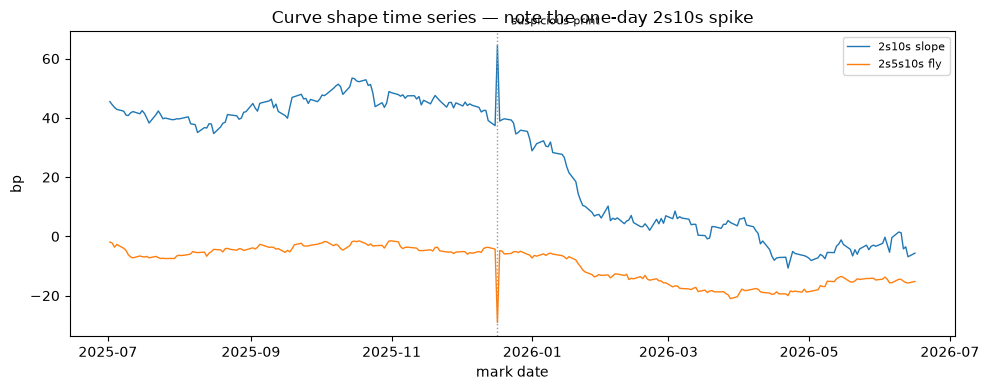

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(key_rates["ts"], 100 * key_rates["s2s10"], lw=1.0, label="2s10s slope")
ax.plot(key_rates["ts"], 100 * key_rates["fly_2_5_10"], lw=1.0, label="2s5s10s fly")
ax.axvline(bad_date, color="0.6", ls=":", lw=1)
ax.annotate("suspicious print", xy=(bad_date, 100 * key_rates.loc[key_rates["ts"] == bad_date, "s2s10"].iloc[0]),
            xytext=(10, 15), textcoords="offset points", fontsize=8)
ax.set_title("Curve shape time series — note the one-day 2s10s spike")
ax.set_xlabel("mark date")
ax.set_ylabel("bp")
ax.legend(fontsize=8)
fig.tight_layout()

## 3. Find the bad mark with a window function

A stale contributor shows up as a one-day round trip: a large day-over-day
change followed by its reversal at the same tenor. Ranking |Δyield| across
all (tenor, date) pairs surfaces it immediately.

In [5]:
db.sql(
    """
    WITH chg AS (
        SELECT ts, tenor_years, yield_pct,
               yield_pct - lag(yield_pct) OVER (PARTITION BY tenor_years ORDER BY ts) AS d1
        FROM curves
    )
    SELECT ts, tenor_years, round(yield_pct, 4) AS yield_pct, round(100 * d1, 1) AS chg_bp
    FROM chg
    WHERE d1 IS NOT NULL
    ORDER BY abs(d1) DESC
    LIMIT 4
    """
).to_pandas()

,ts,tenor_years,yield_pct,chg_bp
0,2025-12-17 21:00:00+00:00,10.00,3.3320,-26.5
1,2025-12-16 21:00:00+00:00,10.00,3.5973,23.8
2,2026-06-05 21:00:00+00:00,0.25,3.4722,-18.8
3,2026-06-05 21:00:00+00:00,0.50,3.3898,-18.7


The top two rows are the same tenor on consecutive dates with opposite
signs — the signature of a bad print, not a market move.

## 4. Restate it — with a preview, a note, and full history

`plan_replace_range` stages the correction against the bad mark date
(range bounds are raw microseconds in `ts` units; the end bound is
exclusive, so `[day_us, day_us + 1)` captures exactly that day's ten rows
since all ten share the same timestamp). We inspect the summary and
samples *before* anything changes, then apply with a note. The desk never
edits history — it appends a corrected version on top.

In [6]:
day_us = int(bad_date.value // 1000)
corrected = clean_df[clean_df["ts"] == bad_date]  # the true marks for that day

plan = db.plan_replace_range(
    "curves", day_us, day_us + 1,
    data=pa.Table.from_pandas(corrected, schema=schema, preserve_index=False),
    note=f"restate {bad_date.date()}: 10y stale contributor, -25bp",
)
print("summary:", plan.summary)
print("\nbefore (10y row):")
print(plan.before_sample.to_pandas().query("tenor_years == 10"))
print("\nafter (10y row):")
print(plan.after_sample.to_pandas().query("tenor_years == 10"))

summary: {'rows_before': 2500, 'rows_after': 2500, 'rows_affected': 10, 'segments_reused': 249, 'segments_added': 1, 'added_bytes': 1322, 'affected_time_range': [1765918800000000, 1765918800000001]}

before (10y row):
                         ts  tenor_years  yield_pct
7 2025-12-16 21:00:00+00:00         10.0     3.5973

after (10y row):
                         ts  tenor_years  yield_pct
7 2025-12-16 21:00:00+00:00         10.0     3.3473


In [7]:
commit = plan.apply()
print(f"applied as v{commit['sequence']} ({commit['op']})")
[
    {k: v[k] for k in ("sequence", "op", "rows", "note") if k in v}
    for v in db.versions("curves")[-2:]
]

applied as v251 (replace_range)


[{'sequence': 250,
  'op': 'append',
  'rows': 2500,
  'note': 'EOD marks 2026-06-15'},
 {'sequence': 251,
  'op': 'replace_range',
  'rows': 2500,
  'note': 'restate 2025-12-16: 10y stale contributor, -25bp'}]

## 5. Point-in-time: what did risk run on that night?

The question that matters after any restatement: *which number did
downstream consumers actually see?* Every version is still addressable —
`h5i('curves', v)` in SQL joins the as-marked view against the restated
head in one query. Overnight risk on the bad date ran on 4.05%; today's
books show 3.80% for the same mark date.

In [8]:
v_pre_restate = db.versions("curves")[-2]["sequence"]  # head just before the restatement
db.sql(
    f"""
    SELECT was.tenor_years,
           round(was.yield_pct, 4) AS as_marked_that_night,
           round(now.yield_pct, 4) AS restated,
           round(100 * (now.yield_pct - was.yield_pct), 1) AS diff_bp
    FROM h5i('curves', {v_pre_restate}) was
    JOIN curves now ON was.ts = now.ts AND was.tenor_years = now.tenor_years
    WHERE was.ts = to_timestamp_micros({day_us}) AND was.tenor_years IN (2, 5, 10, 30)
    ORDER BY was.tenor_years
    """
).to_pandas()

,tenor_years,as_marked_that_night,restated,diff_bp
0,2.0,2.9520,2.9520,0.0
1,5.0,3.1291,3.1291,0.0
2,10.0,3.5973,3.3473,-25.0
3,30.0,3.5568,3.5568,0.0


## 6. Carry & rolldown from the latest curve

Standard unchanged-curve arithmetic for a 5y position over a 1y horizon,
interpolating the stored tenors: **rolldown** is the yield pickup from
aging 5y → 4y on today's curve; **carry** is the yield over 3m funding —
negative here, since this simulated curve ends the year inverted at the
front. Both are yield-space approximations (multiply by duration for price
space) — fine for a relative-value screen, not a P&L forecast.

In [9]:
latest = db.sql(
    "SELECT tenor_years, yield_pct FROM curves WHERE ts = (SELECT max(ts) FROM curves) ORDER BY tenor_years"
).to_pandas()

tenors, ylds = latest["tenor_years"].values, latest["yield_pct"].values
y = lambda t: float(np.interp(t, tenors, ylds))

rolldown_bp = 100 * (y(5) - y(4))
carry_bp = 100 * (y(5) - y(0.25))
dur_4y = 3.7  # rough modified duration of the aged position
print(f"5y yield {y(5):.3f}%, 4y yield {y(4):.3f}%, 3m funding {y(0.25):.3f}%")
print(f"rolldown (1y horizon): {rolldown_bp:+.1f} bp  (~{rolldown_bp * dur_4y / 100:+.2f}% price)")
print(f"carry over funding:    {carry_bp:+.1f} bp")
print(f"carry + roll:          {carry_bp + rolldown_bp:+.1f} bp per year, curve unchanged")

5y yield 3.043%, 4y yield 3.060%, 3m funding 3.506%
rolldown (1y horizon): -1.7 bp  (~-0.06% price)
carry over funding:    -46.4 bp
carry + roll:          -48.0 bp per year, curve unchanged


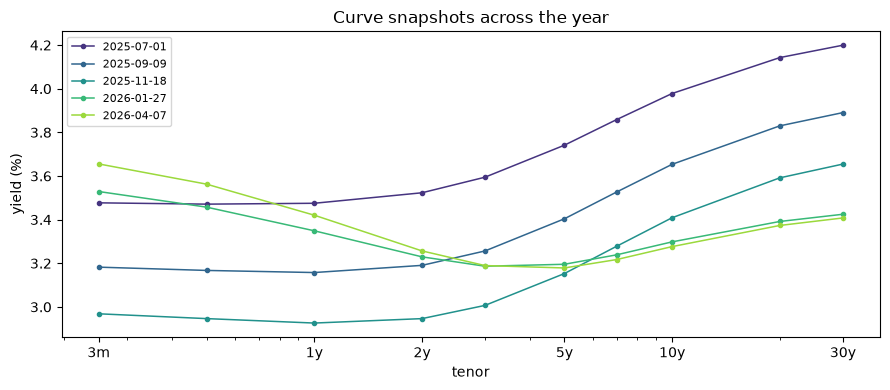

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
show_dates = mark_dates[:: len(mark_dates) // 5][:6]
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(show_dates)))
for d, c in zip(show_dates, colors):
    g = clean_df[clean_df["ts"] == d]
    ax.plot(g["tenor_years"], g["yield_pct"], marker="o", ms=3, lw=1.1,
            color=c, label=str(pd.Timestamp(d).date()))
ax.set_xscale("log")
ax.set_xticks([0.25, 1, 2, 5, 10, 30])
ax.set_xticklabels(["3m", "1y", "2y", "5y", "10y", "30y"])
ax.set_title("Curve snapshots across the year")
ax.set_xlabel("tenor")
ax.set_ylabel("yield (%)")
ax.legend(fontsize=8)
fig.tight_layout()

## Takeaways

- Long format `(ts, tenor_years, yield_pct)` + one commit per mark date
  turns the curve history into a versioned, SQL-queryable marking diary.
- Conditional-aggregation pivots and `lag()` windows cover the standing
  analytics — slope, fly, day-over-day outlier detection — without ever
  reshaping data outside the database.
- Restatements are `plan_replace_range`: microsecond range bounds
  (end-exclusive) select the mark date, the preview shows exactly what
  changes, and the note lands in `versions()` as the audit record.
- Point-in-time is free: `h5i('curves', v)` joined against the head answers
  "what did risk run on that night?" with provenance, not archaeology.
- Carry/rolldown and similar curve math read naturally off the stored
  tenors — the database serves marks, pandas does the interpolation.

In [11]:
db.close()